<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework%203/Problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of features: 30
Training samples: 455
Testing samples: 114


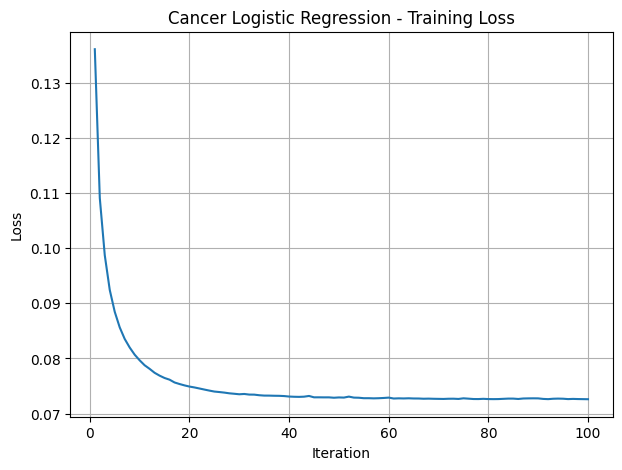

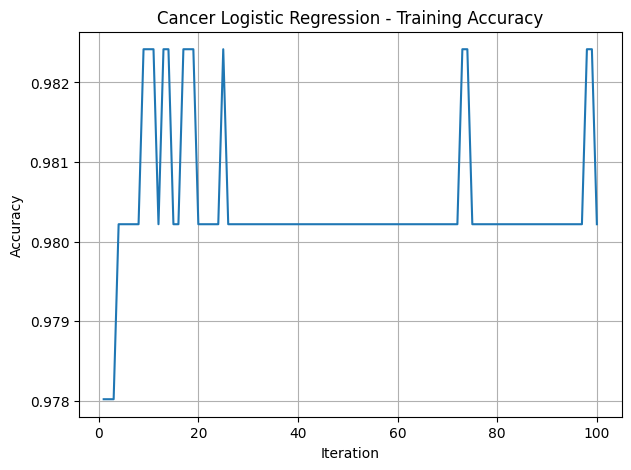

Accuracy : 0.9825
Precision: 1.0
Recall   : 0.9524
F1 Score : 0.9756


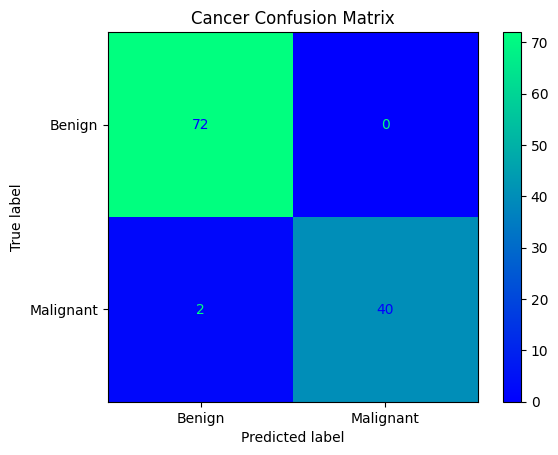

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    ConfusionMatrixDisplay
)

# Load dataset
df = pd.read_csv("Cancer.csv")

# Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis into numbers
# Benign = 0
# Malignant = 1
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Input and output
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Number of features:", X.shape[1])

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# Weight penalty to logistic regression model
model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

# Store loss and accuracy
loss_history = []
accuracy_history = []

epochs = 100
classes = np.array([0, 1])

rng = np.random.default_rng(42)

# Train model
for epoch in range(epochs):

    # Shuffle training data
    index = rng.permutation(len(y_train))

    X_epoch = X_train[index]
    y_epoch = y_train[index]

    # Train one iteration
    model.partial_fit(
        X_epoch,
        y_epoch,
        classes=classes
    )

    # Calculate loss
    y_probability = model.predict_proba(X_train)[:, 1]

    loss = log_loss(
        y_train,
        y_probability
    )

    # Calculate training accuracy
    y_train_pred = model.predict(X_train)

    accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    loss_history.append(loss)
    accuracy_history.append(accuracy)


# Plot Loss
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Cancer Logistic Regression - Training Loss")
plt.grid()

plt.show()


# Plot Accuracy
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history
)

plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Cancer Logistic Regression - Training Accuracy")
plt.grid()

plt.show()


# Test model
y_pred = model.predict(X_test)

# Calculate results
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

# Print results
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Benign", "Malignant"],
    cmap="winter"
)

plt.title("Cancer Confusion Matrix")

plt.show()